In [1]:
from compute_psth import *

In [2]:
SEED = 42
N_NEURONS = 20          # number of random neurons to sample
SHEET_NAME = "V1_Exc_L2/3"
ST_NAME = "PixelMovieExperanto"
OUTPUT_DIR = "results/psth_9sec"

In [3]:
dataset = PickledDataStore(
            load=True,
            parameters=ParameterSet({
                "root_directory": f"SelfSustainedPushPull_test:AB_1sec_100trials_____",
                "store_stimuli": False,
            }),
            replace=False,
        )

In [4]:
dsv = param_filter_query(dataset, st_name=ST_NAME, sheet_name=SHEET_NAME)
segs = dsv.get_segments()
parsed = [(seg, parse_stimulus(seg.annotations['stimulus'])) for seg in segs]
parsed.sort(key=lambda x: x[1]['trial'])

# Filter segments to keep only those matching the first segment's movie_name
movie_name = parsed[0][1]['movie_name']
print(movie_name)
parsed = [(seg, stim) for seg, stim in parsed if stim['movie_name'] == movie_name]

segment_cache = parsed

00005.npy


In [5]:
# # first_cond = segment_cache[0]
# # all_segments = [seg for seg, _ in segment_cache[first_cond]]
# all_ids = collect_neuron_ids([segment_cache[0][0]])
# print(f"Total neurons found: {len(all_ids)}")

# neuron_ids = sorted(random.sample(all_ids, min(N_NEURONS, len(all_ids))))
# print(f"Sampled {len(neuron_ids)} neurons for PSTH")
# print(neuron_ids)

In [6]:
print("Finding most active neurons...")
all_segments = [seg for seg, _ in segment_cache[:]]
    
activity_map = defaultdict(int)
total_duration = 0

for seg in tqdm(all_segments[:]):
    t_start = float(seg.t_start.rescale('s').magnitude)
    t_stop = float(seg.t_stop.rescale('s').magnitude)
    total_duration += (t_stop - t_start)
    
    for st in seg.spiketrains:
        uid = st.annotations.get('source_id', st.name)
        activity_map[uid] += len(st) # Count total spikes

# Calculate mean rate (Hz) and sort
# We divide by total_duration to get spikes/second
neuron_activity = [
    (uid, count / total_duration) for uid, count in activity_map.items()
]
# Sort by Hz descending
neuron_activity.sort(key=lambda x: x[1], reverse=True)

# Pick the top N
neuron_ids = [uid for uid, rate in neuron_activity[:N_NEURONS]]

print(f"Top {len(neuron_ids)} active neurons selected.")
print(neuron_ids)

Finding most active neurons...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [48:27<00:00, 14.54s/it]

Top 20 active neurons selected.
[85971, 63880, 72079, 68291, 64346, 75298, 67768, 62474, 95713, 82913, 97242, 91886, 86240, 71573, 80214, 84893, 91687, 63649, 83677, 98398]


In [5]:
# a = set([85971, 63880, 64346, 72079, 68291, 75298, 63649, 62474, 67768, 82913, 65661, 95713, 71373, 83677, 80214, 84893, 71573, 86240, 87123, 91886])
# neuron_ids = set([63880, 85971, 72079, 64346, 75298, 68291, 67768, 82913, 62474, 83677, 63649, 86240, 91886, 97242, 63899, 71573, 95713, 80214, 91687, 81969])
neuron_ids = [85971, 63880, 72079, 68291, 64346, 75298, 67768, 62474, 95713, 82913, 97242, 91886, 86240, 71573, 80214, 84893, 91687, 63649, 83677, 98398]

In [8]:
# len(a & b)

In [9]:
# import neo.core
# from tqdm import tqdm

# def get_filtered_segments(segment_tuples, neuron_ids):
#     neuron_set = set(neuron_ids)
#     filtered_segments = []
    
#     # segment_tuples is a list of (MozaikSegment, stimulus_annotation)
#     for seg, stim in tqdm(segment_tuples, desc="Filtering Neurons", leave=False):
#         # 1. Create a standard Neo Segment
#         # We don't set t_start/t_stop directly; they are derived from data.
#         new_seg = neo.core.Segment(name=getattr(seg, 'name', 'PSTH_Segment'))
        
#         # Copy annotations to keep trial metadata (like movie_name)
#         new_seg.annotations = seg.annotations.copy()
        
#         # 2. Extract only the target spiketrains
#         # This is the core optimization to stop the slowdown
#         target_st = [
#             st for st in seg.spiketrains 
#             if st.annotations.get('source_id', st.name) in neuron_set
#         ]
        
#         # 3. Use the standard Neo method to add spiketrains
#         # This will automatically set the segment's temporal extent correctly
#         new_seg.spiketrains.extend(target_st)
        
#         filtered_segments.append(new_seg)
        
#     return filtered_segments

# # --- Execution ---
# print("Preparing lightweight segments...")
# # Use the tuples from your notebook's cache
# fast_segs = get_filtered_segments(segment_cache, neuron_ids)

# print(f"Filtering complete. Created {len(fast_segs)} lightweight segments.")

# # # Now run the PSTH calculation
# # # Because fast_segs has 20 neurons instead of 37,500, this will be very fast.
# # psth_dict, bin_edges_ms = corrected_compute_psth(
# #     fast_segs, 
# #     neuron_ids=neuron_ids, 
# #     bin_size_ms=BIN_SIZE_MS
# # )

In [10]:
# def fast_compute_psth(segments, neuron_ids, bin_size_ms=BIN_SIZE_MS):
#     bin_size_s = bin_size_ms / 1000.0
#     n_trials = len(segments)
    
#     # 1. Setup time extent
#     seg0 = segments[0]
#     t_start_s = float(seg0.t_start.rescale('s').magnitude)
#     t_stop_s = float(seg0.t_stop.rescale('s').magnitude)
#     duration_s = t_stop_s - t_start_s
#     n_bins = int(np.ceil(duration_s / bin_size_s))
    
#     # 2. Pre-extract ONLY the target neurons (The Speed Boost)
#     # This avoids iterating over 37,500 neurons inside the trial loop
#     print(f"Pre-extracting spiketrains for {len(neuron_ids)} neurons...")
#     target_spiketrains = {uid: [None] * n_trials for uid in neuron_ids}
#     id_to_idx = {uid: i for i, uid in enumerate(neuron_ids)}
    
#     for trial_idx, seg in enumerate(tqdm(segments)):
#         for st in seg.spiketrains:
#             uid = st.annotations.get('source_id', st.name)
#             if uid in id_to_idx:
#                 # Store the relative spike times immediately
#                 target_spiketrains[uid][trial_idx] = st.rescale('s').magnitude - float(seg.t_start.rescale('s').magnitude)

#     # 3. Compute histograms (Now much faster)
#     psth_dict = {}
#     for uid in tqdm(neuron_ids, desc="Binning Spikes"):
#         # Flatten all spikes for this neuron across all trials for a vectorized histogram
#         # We then divide by n_trials at the end
#         all_spikes = np.concatenate([s for s in target_spiketrains[uid] if s is not None])
        
#         counts, _ = np.histogram(all_spikes, bins=n_bins, range=(0.0, n_bins * bin_size_s))
        
#         # Mean Hz = (Total Counts / Num Trials) / Bin Width
#         psth_dict[uid] = (counts / n_trials) / bin_size_s

#     bin_edges_ms = np.arange(n_bins + 1) * bin_size_ms
#     return psth_dict, bin_edges_ms

In [ ]:
BIN_SIZE_MS = 10         # PSTH bin width in milliseconds
segs = [seg for seg, _ in segment_cache[0:]]
# psth_dict, bin_edges_ms = corrected_compute_psth(segs, neuron_ids=neuron_ids, bin_size_ms=BIN_SIZE_MS)
population_psth, population_sem, bin_edges_ms = compute_population_psth(segs, neuron_ids=all_neuron_ids[:20], bin_size_ms=BIN_SIZE_MS)

Computing Pop. PSTH:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                                   | 72/100 [03:37<05:32, 11.87s/it]

In [15]:
# """
# Plot a grid of PSTHs (one subplot per neuron) and save as PNG.
# """
# n_cols=10
# n_neurons = len(neuron_ids)
# n_rows = int(np.ceil(n_neurons / n_cols))
# bin_centres_ms = (bin_edges_ms[:-1] + bin_edges_ms[1:]) / 2.0

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 1.8 * n_rows),
#                          sharex=True, sharey=False)
# axes = np.atleast_2d(axes)

# for idx, uid in enumerate(neuron_ids):
#     row, col = divmod(idx, n_cols)
#     ax = axes[row, col]
#     ax.bar(bin_centres_ms, psth_dict[uid],
#            width=bin_edges_ms[1] - bin_edges_ms[0],
#            color='steelblue', edgecolor='none', alpha=0.8)
#     ax.set_title(f"N{uid}", fontsize=6, pad=2)
#     ax.tick_params(labelsize=5)

# # Hide unused subplots
# for idx in range(n_neurons, n_rows * n_cols):
#     row, col = divmod(idx, n_cols)
#     axes[row, col].set_visible(False)

# fig.suptitle(f"PSTH — {condition_name}  (bin={bin_edges_ms[1]:.0f} ms)", fontsize=12)
# fig.supxlabel("Time (ms)", fontsize=9)
# fig.supylabel("Firing rate (Hz)", fontsize=9)
# fig.tight_layout(rect=[0.02, 0.02, 1, 0.96])

# plt.show()

# # save_path = os.path.join(output_dir, f"{condition_name}_psth_grid.png")
# # # fig.savefig(save_path, dpi=150)
# # plt.close(fig)
# # print(f"  Saved plot: {save_path}")

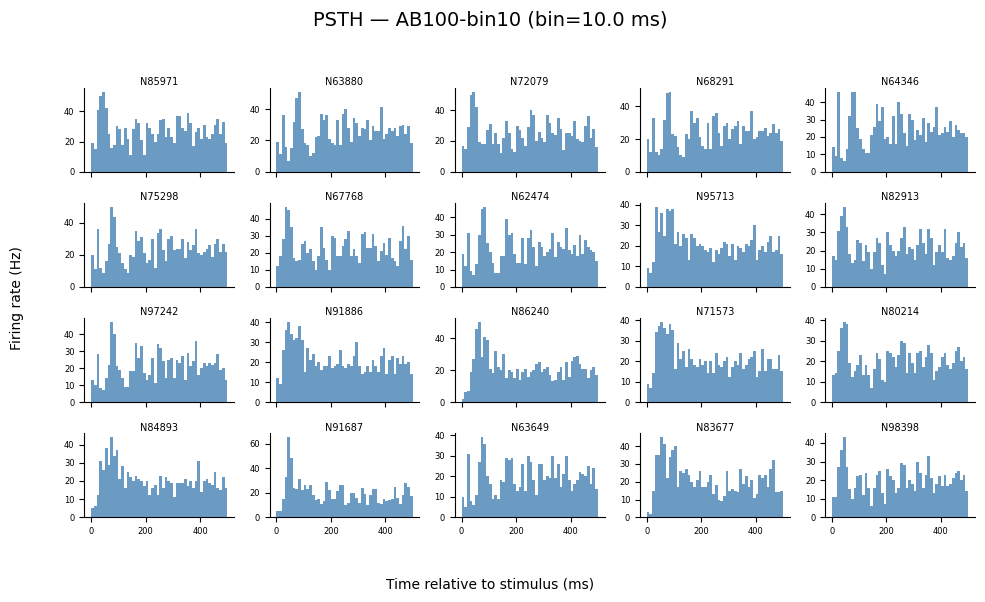

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

# --- Assumptions for this to run ---
# psth_dict: {uid: array_of_rates}
# bin_edges_ms: array of edges from your previous function
# neuron_ids: list of the IDs you want to plot
# condition_name: string (e.g., "Stimulus A")
# -----------------------------------

n_cols = 1
condition_name = f"AB{len(segs)}-bin{BIN_SIZE_MS}"
n_neurons = len(neuron_ids)
n_rows = int(np.ceil(n_neurons / n_cols))
bin_centres_ms = (bin_edges_ms[:-1] + bin_edges_ms[1:]) / 2.0
bin_width = bin_edges_ms[1] - bin_edges_ms[0]

# 1. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(2 * n_cols, 1.5 * n_rows), # Adjusted for tight grids
                         sharex=True, 
                         sharey=False)

# 2. Flatten axes safely to handle both 1D and 2D cases
# This makes it much easier to iterate than using row/col indices
flat_axes = axes.flatten() if n_neurons > 1 else [axes]

for idx, uid in enumerate(neuron_ids):
    ax = flat_axes[idx]
    
    # Plotting the PSTH
    ax.plot(bin_centres_ms, psth_dict[uid],
           width=bin_width,
           color='steelblue', 
           edgecolor='none', 
           alpha=0.8,
           align='center')
    
    # Minimalist styling for dense grids
    ax.set_title(f"N{uid}", fontsize=7, pad=2)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Optional: Despine to make it look cleaner
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 3. Hide any empty subplots at the end of the grid
for i in range(idx + 1, len(flat_axes)):
    flat_axes[i].axis('off')

# 4. Global labels and layout
# fig.suptitle(f"PSTH — {condition_name} (bin={bin_width:.1f} ms)", fontsize=14)
fig.supxlabel("Time relative to stimulus (ms)", fontsize=10)
fig.supylabel("Firing rate (Hz)", fontsize=10)

# Adjust layout to prevent title overlap
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])

# 5. Save and Show
plt.savefig(f"psth_grid_{condition_name}.png", dpi=300)
plt.show()

In [10]:
neuron_ids1 = [i+1 for i in neuron_ids]

In [14]:
neuron_ids1= neuron_ids1 + neuron_ids

In [15]:
neuron_ids1

[85972,
 63881,
 72080,
 68292,
 64347,
 75299,
 67769,
 62475,
 95714,
 82914,
 97243,
 91887,
 86241,
 71574,
 80215,
 84894,
 91688,
 63650,
 83678,
 98399,
 85971,
 63880,
 72079,
 68291,
 64346,
 75298,
 67768,
 62474,
 95713,
 82913,
 97242,
 91886,
 86240,
 71573,
 80214,
 84893,
 91687,
 63649,
 83677,
 98398]

In [29]:
all_segments = [seg for seg, _ in segment_cache[:]]
all_neuron_ids = np.zeros(37500)
seg = all_segments[0]
print(len(seg.spiketrains))
for i, st in enumerate(tqdm(seg.spiketrains)):
    uid = st.annotations.get('source_id', st.name)
    all_neuron_ids[i] = uid

37500


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37500/37500 [00:00<00:00, 810061.49it/s]


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def fast_plot_population_psth(segments, neuron_ids, bin_size_ms=10):
    bin_size_s = bin_size_ms / 1000.0
    n_trials = len(segments)
    
    seg0 = segments[0]
    t_start_s = float(seg0.t_start.rescale('s').magnitude)
    t_stop_s = float(seg0.t_stop.rescale('s').magnitude)
    duration_s = t_stop_s - t_start_s
    n_bins = int(np.ceil(duration_s / bin_size_s))
    
    pop_spikes = []
    neuron_set = set(neuron_ids)
    
    for seg in tqdm(segments, desc="Extracting Spikes"):
        seg_t_start = float(seg.t_start.rescale('s').magnitude)
        for st in seg.spiketrains:
            if st.annotations.get('source_id', st.name) in neuron_set:
                spikes_s = st.rescale('s').magnitude - seg_t_start
                pop_spikes.append(spikes_s)
    
    if pop_spikes:
        all_spikes = np.concatenate(pop_spikes)
        counts, _ = np.histogram(all_spikes, bins=n_bins, range=(0.0, n_bins * bin_size_s))
        
        # Calculate mean firing rate (Hz)
        pop_psth = (counts / n_trials / len(neuron_ids)) / bin_size_s
    else:
        pop_psth = np.zeros(n_bins)
        
    bin_edges_ms = np.arange(n_bins + 1) * bin_size_ms
    bin_centres_ms = (bin_edges_ms[:-1] + bin_edges_ms[1:]) / 2.0
    
    plt.figure(figsize=(10, 4))
    plt.plot(bin_centres_ms, pop_psth, color='black', linewidth=1.5)
    plt.title(f"Population PSTH (n={len(neuron_ids)} neurons, {n_trials} trials, bin={bin_size_ms}ms)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Firing Rate (Hz)")
    
    # Despine for a cleaner look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"output_all.png", dpi=300)
    plt.show()

    return bin_centres_ms, pop_psth


In [43]:
# Execution
segs = [seg for seg, _ in segment_cache]
bin_centres_ms, pop_psth = fast_plot_population_psth(segs, all_neuron_ids, bin_size_ms=BIN_SIZE_MS)

np.save("out_bin_centres_ms.npy", bin_centres_ms)
np.save("out_pop_psth.npy", pop_psth)

Extracting Spikes:   2%|█████▉                                                                                                                                                                                                                                                                                                     | 2/100 [02:56<2:24:05, 88.22s/it]


KeyboardInterrupt: 